In [297]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

import joblib
import ipywidgets as widgets

In [298]:
df = pd.read_excel(r'C:\DS CLASS 2\portofolio_intern\personal\global_supply_chain_disruption_v1.csv.xlsx')

print("Data loaded successfully")
display(df.head())


Data loaded successfully


,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping


In [299]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

df.info()
df.describe()

Missing values per column:
Order_ID                       0
Order_Date                     0
Origin_City                    0
Destination_City               0
Route_Type                     0
Transportation_Mode            0
Product_Category               0
Base_Lead_Time_Days            0
Scheduled_Lead_Time_Days       0
Actual_Lead_Time_Days          0
Delay_Days                     0
Delivery_Status                0
Disruption_Event            8733
Geopolitical_Risk_Index        0
Weather_Severity_Index         0
Inflation_Rate_Pct             0
Shipping_Cost_USD              0
Order_Weight_Kg                0
Mitigation_Action_Taken        0
dtype: int64

Number of duplicate rows:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  10000 non-null  object        
 1   Order

,Order_Date,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
count,10000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2024-12-29 13:37:20.639999744,17.509900,19.50320,18.704300,0.947500,0.496770,4.976460,3.516010,11437.916337,5033.732500
min,2024-01-04 00:00:00,2.000000,3.00000,1.000000,0.000000,0.100000,0.000000,-1.150000,59.940000,101.000000
25%,2024-07-01 00:00:00,7.000000,9.00000,7.000000,0.000000,0.300000,2.500000,2.700000,2308.387500,2590.500000
50%,2024-12-27 00:00:00,18.000000,20.00000,18.000000,0.000000,0.500000,4.900000,3.500000,4520.170000,5044.500000
75%,2025-07-01 00:00:00,28.000000,29.00000,28.000000,0.000000,0.690000,7.500000,4.350000,7055.107500,7493.000000
max,2026-01-03 00:00:00,35.000000,38.00000,49.000000,20.000000,0.900000,10.000000,7.920000,206814.290000,9999.000000
std,NaN,10.902843,10.93356,11.662815,3.117293,0.230611,2.879658,1.209597,21086.689659,2830.996788


In [300]:
df['High_Delay_Risk'] = np.where(df['Delay_Days'] > 3, 1, 0)

print("Target Distribution (%):")
print(df['High_Delay_Risk'].value_counts(normalize=True) * 100)

df['Month'] = df['Order_Date'].dt.month
df['Cost_per_Kg'] = df['Shipping_Cost_USD'] / df['Order_Weight_Kg']
df['Is_High_GeoRisk'] = (df['Geopolitical_Risk_Index'] > 70).astype(int)
df['Is_Severe_Weather'] = (df['Weather_Severity_Index'] > 70).astype(int)

Target Distribution (%):
High_Delay_Risk
0    91.18
1     8.82
Name: proportion, dtype: float64


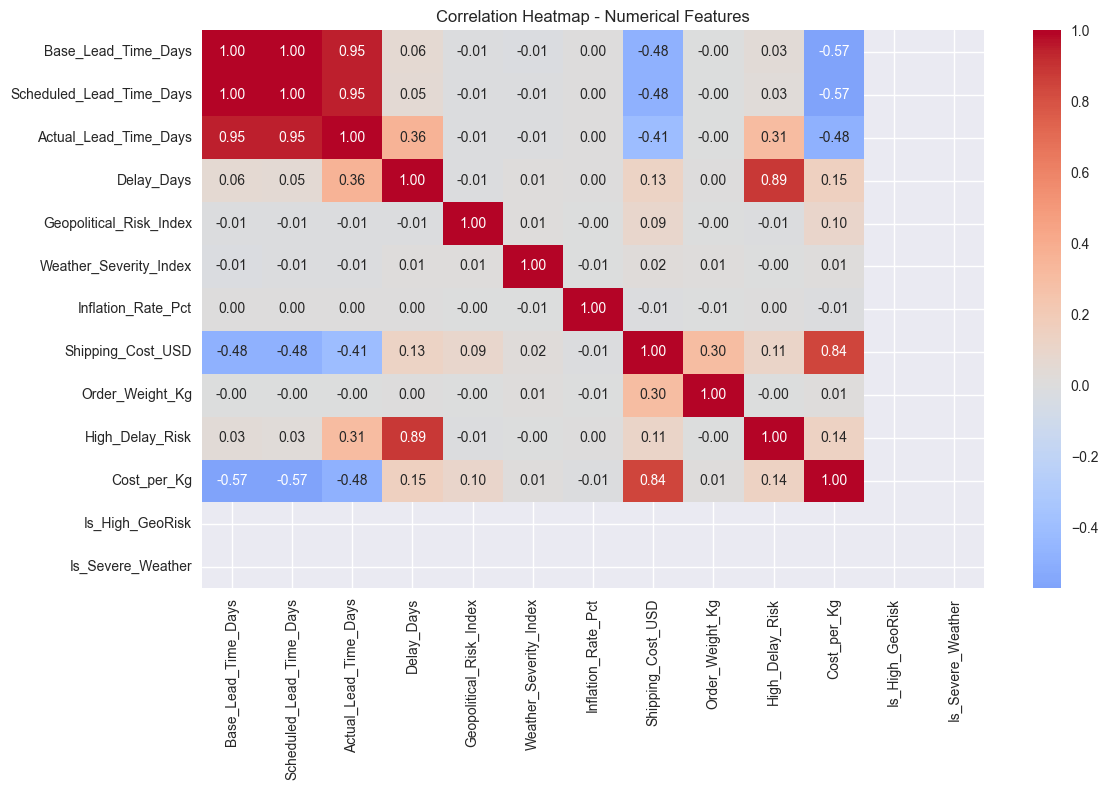

In [301]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()


In [302]:
df_model = df.drop(columns=[
    'Order_ID',
    'Delay_Days',
    'Delivery_Status',
    'Actual_Lead_Time_Days',
    'Base_Lead_Time_Days',
    'Scheduled_Lead_Time_Days',
    'Order_Date'
])


In [303]:
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop('High_Delay_Risk', axis=1)
y = df_model['High_Delay_Risk']

print("Final feature shape:", X.shape)


Final feature shape: (10000, 34)


In [304]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [305]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [306]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print("Average CV ROC-AUC:", cv_scores.mean())


Average CV ROC-AUC: 0.9935687219905525


In [307]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1824
           1       0.94      0.70      0.81       176

    accuracy                           0.97      2000
   macro avg       0.96      0.85      0.89      2000
weighted avg       0.97      0.97      0.97      2000

ROC AUC: 0.9937294407894737


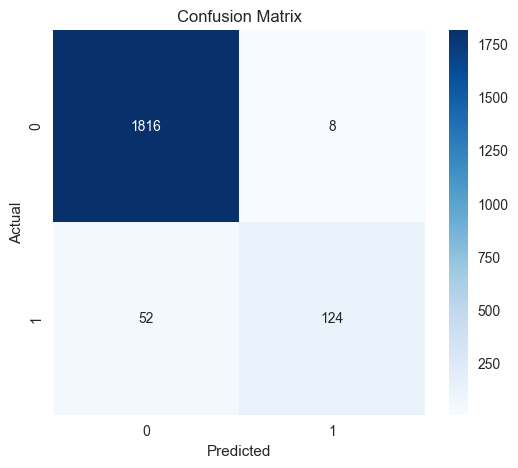

In [308]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


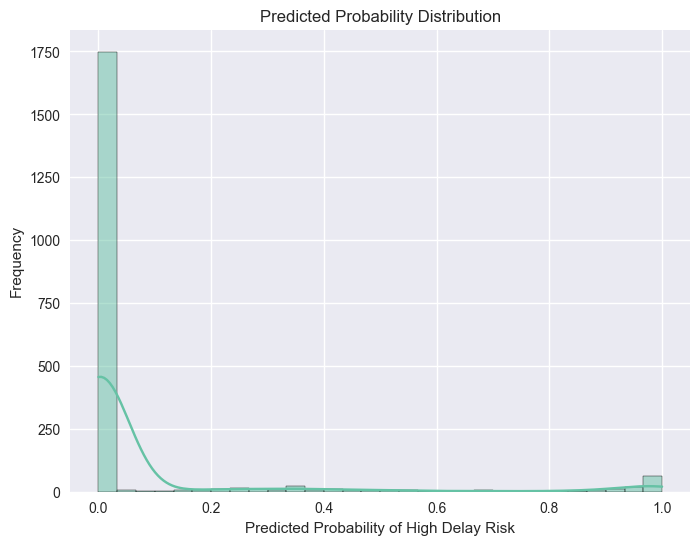

In [309]:
evaluation_df = X_test.copy()
evaluation_df['Actual'] = y_test.values
evaluation_df['Predicted'] = y_pred
evaluation_df['Probability'] = y_prob

plt.figure(figsize=(8,6))
sns.histplot(evaluation_df['Probability'], bins=30, kde=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability of High Delay Risk")
plt.ylabel("Frequency")
plt.show()


In [310]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.head(10)


,Feature,Importance
33,Mitigation_Action_Taken_Standard Shipping,0.252276
6,Cost_per_Kg,0.173619
30,Disruption_Event_Port Congestion,0.145598
32,Mitigation_Action_Taken_Re-routing,0.087202
31,Disruption_Event_Severe Weather (Typhoon/Storm),0.086054
3,Shipping_Cost_USD,0.040343
0,Geopolitical_Risk_Index,0.028989
22,Route_Type_Suez,0.026822
4,Order_Weight_Kg,0.022637
2,Inflation_Rate_Pct,0.020641


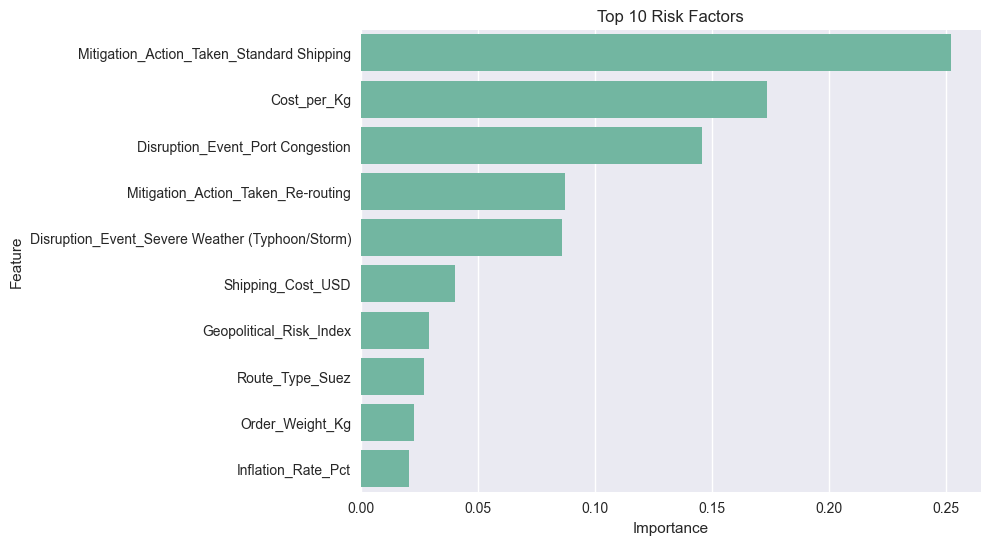

In [311]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top 10 Risk Factors")
plt.show()


In [312]:
joblib.dump(rf, "rf_delay_model.pkl")


['rf_delay_model.pkl']

In [313]:
trained_columns = X_train.columns
model = rf

def predict_risk(geo_risk, weather, cost_per_kg):

    input_data = pd.DataFrame({
        'Geopolitical_Risk_Index': [geo_risk],
        'Weather_Severity_Index': [weather],
        'Cost_per_Kg': [cost_per_kg]
    })

    input_data = input_data.reindex(columns=trained_columns, fill_value=0)

    probability = model.predict_proba(input_data)[0][1]

    print(f"Predicted Delay Risk Probability: {probability:.2f}")

    if probability < 0.3:
        print("Risk Level: LOW")
    elif probability < 0.7:
        print("Risk Level: MEDIUM")
    else:
        print("Risk Level: HIGH")

widgets.interact(
    predict_risk,
    geo_risk=(0, 100, 5),
    weather=(0, 100, 5),
    cost_per_kg=(1, 500, 10)
)


interactive(children=(IntSlider(value=50, description='geo_risk', step=5), IntSlider(value=50, description='we…

<function __main__.predict_risk(geo_risk, weather, cost_per_kg)>